In [ ]:
import pandas as pd 
import numpy as np 


In [76]:
df=pd.read_csv('iris.csv')

In [77]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.shape

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.isna().sum()

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split as tts 
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import  ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt


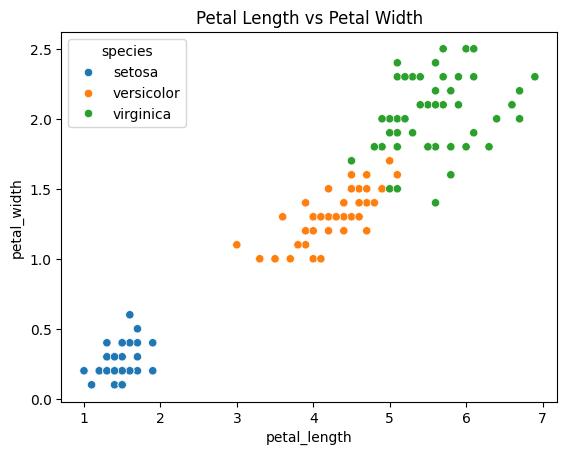

In [80]:
plt.figure()

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)

plt.title("Petal Length vs Petal Width")

plt.show()

# Data Preprocessing

In [81]:
def encoder():
    obj_cols=df.select_dtypes(['object']).columns
    LE=LabelEncoder()
    for i in obj_cols:
        df[i]=LE.fit_transform(df[i])
    return LE
    

# Model Training

In [82]:
model_pipeline=Pipeline(
    [("model",RandomForestClassifier())]
)

In [83]:
x=df.drop(columns=['species'])
LE=encoder()
y=df['species']


In [84]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

In [ ]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=20)

In [ ]:
model_pipeline.fit(x_train,y_train)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pd=model_pipeline.predict(x_test)
acc=accuracy_score(y_test,y_pd)
acc

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pd)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# HyperParameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "model__n_estimators": [50,100,200],
    "model__max_depth": [None,5,10],
    "model__min_samples_split": [2,4,6],
    "model__min_samples_leaf": [1,2,3]
}

In [ ]:
grid = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

In [ ]:
grid.best_params_

In [85]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

from sklearn.metrics import accuracy_score

acc2=accuracy_score(y_test, y_pred)
acc2

0.9

## Saving Model

In [86]:
import joblib,os

In [87]:
def save_model(path="iris_flower_classifier_model.pkl"):
    if os.path.exists(path):
        choice = input("Model already exists. Do you want to replace it? (y/n): ").strip().lower()
        if choice != "y":
            print("Model was not replaced.")
            return

    joblib.dump((best_model,LE), path)
    print("Model saved successfully.")
save_model()

Model saved successfully.
